## **0. Initialization**

### **Installation**
LoopDetectR is on CRAN and can be installed within R by

In [ ]:
# Before running the R code cells in jupyter notebook,
# initialize the R kernel by this line of code:
# IRkernel::installspec()

In [ ]:
# Download and install
install.packages("LoopDetectR")

Installing package into 'C:/Users/Admin/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'LoopDetectR' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\Admin\AppData\Local\Temp\Rtmpk1kCL5\downloaded_packages


In [ ]:
install.packages("deSolve")  # if not already installed
install.packages("numDeriv") # if not already installed

Installing package into 'C:/Users/Admin/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'deSolve' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\Admin\AppData\Local\Temp\Rtmpk1kCL5\downloaded_packages


Installing package into 'C:/Users/Admin/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'numDeriv' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\Admin\AppData\Local\Temp\Rtmpk1kCL5\downloaded_packages


In [2]:
# Load package
library("LoopDetectR")
library(deSolve)
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [3]:
colors <- c('#EE7733', '#0077BB', '#33BBEE', '#EE3377', '#CC3311', '#009988', '#BBBBBB')

## **1. Model definition**

#### **Example 6: Calcium oscillations model**

The reactions (flows) constituting the model are given by
$$
\begin{aligned}
\nu_1 &= k_1,\\[6pt]
\nu_2 &= k_2,\\[6pt]
\nu_3 &= k_3 \cdot \frac{S_1^{n_1}}{kn_1^{\,n_1} + S_1^{n_1}},\\[10pt]
\nu_4 &= k_4 \cdot 
       \frac{S_2^{n_2}}{kn_2^{\,n_2} + S_2^{n_2}} \cdot
       \frac{S_1^{n_3}}{kn_3^{\,n_3} + S_1^{n_3}},\\[10pt]
\nu_5 &= k_5 \cdot S_2,\\[6pt]
\nu_6 &= k_6 \cdot S_1.
\end{aligned}
$$

The model is composed from these six reactions by
$$
\begin{aligned}
\frac{dS_1}{dt} &= \nu_1 + \nu_2 - \nu_3 + \nu_4 + \nu_5 - \nu_6,\\[6pt]
\frac{dS_2}{dt} &= \nu_3 - \nu_4 - \nu_5.
\end{aligned}
$$


In [17]:
model_calcium_oscillation <- function(t, y, klin, kn, n0) {
  # Unpack state variables
  S1 <- y[1]
  S2 <- y[2]

  # Kinetic parameters
  k1 <- klin[1]; k2 <- klin[2]; k3 <- klin[3]
  k4 <- klin[4]; k5 <- klin[5]; k6 <- klin[6]

  # Saturation constants
  kn1 <- kn[1]; kn2 <- kn[2]; kn3 <- kn[3]

  # Hill exponents
  n1 <- n0[1]; n2 <- n0[2]; n3 <- n0[3]

  # Reaction rates
  v1 <- k1
  v2 <- k2
  v3 <- k3 * (S1^n1) / (kn1^n1 + S1^n1)
  v4 <- k4 *
        (S2^n2) / (kn2^n2 + S2^n2) *
        (S1^n3) / (kn3^n3 + S1^n3)
  v5 <- k5 * S2
  v6 <- k6 * S1

  # ODEs
  dS1 <- v1 + v2 - v3 + v4 + v5 - v6
  dS2 <- v3 - v4 - v5

  dx = rep(0, 2)
  dx[1] = dS1
  dx[2] = dS2
  return(dx)
}

## **2. Result reproduction**

In [28]:
# Parameters from supplementary material
initial_conditions_calcium <- c(0.3920, 1.6456)
klin_calcium <- c(1, 7.3 * 0.4, 65, 500, 1, 10) # Fix k2 to 40% of original value as the new params from Prof. Baum
kn_calcium <- c(1, 2, 0.9)
n_calcium <- c(2, 2, 4)
time_points <- seq(0, 3, length.out = 301)

# Additional variables 
all_labels <- c("S1", "S2")

### **2.1. Reduced Calcium Oscillations Model**

#### **2.1.1. Loop structure (at first)**

In [18]:
# compute loops
res_tab <- find_loops_vset(model_calcium_oscillation,vset=list(initial_conditions_calcium),t=1,klin=klin_calcium,kn=kn_calcium,n0=n_calcium)
# The loop list is reported
res_tab$loop_rep[[1]] 
# To access a specific loop representation: e.g., the sixth loop, add [6,]

loop,length,sign
<I<list>>,<dbl>,<dbl>
"1, 1",1,1
"2, 2",1,-1
"1, 2, 1",2,-1


In [10]:
loop_summary(res_tab$loop_rep[[1]])

,len_1,len_2
,<dbl>,<dbl>
all,2,1
pos,1,0
neg,1,1


In [11]:
# Index of node of interest
noi <- 2 
# Return all loops from loop_list containing node 2
loop_list <- res_tab$loop_rep[[1]]
loop_list[vapply(loop_list$loop,function(x){noi %in% x},logical(1)),]

,loop,length,sign
,<I<list>>,<dbl>,<dbl>
2,"2, 2",1,-1
3,"1, 2, 1",2,-1


#### **2.1.2. Calculating the Jacobian matrix**

Sign jacobian matrix can be access via `res_tab` variable that we have calculated above, or derived from a jacobian matrix at a specific state

In [12]:
# The corresponding signed Jacobian matrix (at initialization point)
res_tab$jac_rep[[1]]

1,1
-1,-1


The function jacobian from the numDeriv package can be used to determine numerically the Jacobian matrix of an ODE system at a certain set of values for the variables, `s_star`. The approach is that of finite differences (with real step) or complex step approach, the latter of which is supposed to deliver more exact results [Martins et al., 2003].

In [21]:
func_list <- function(t,x,klin,kn,n0){list(model_calcium_oscillation(t,x,klin,kn,n0))}
sol <-  deSolve::ode(y = initial_conditions_calcium, times = time_points, func = func_list, 
                     parms=klin_calcium, kn=kn_calcium, n0=n_calcium)
    
# Set the last point of the numeric solution as point of interest, omit the 
# first column (it contains the time)
s_star_end <- sol[dim(sol)[1],2:dim(sol)[2]]
s_star_end

1         2 
0.3106113 1.8764494

In [22]:
j_matrix <- numDeriv::jacobian(model_calcium_oscillation, s_star_end,method="complex",
                               t=3650,klin=klin_calcium, kn=kn_calcium, n0=n_calcium)
j_matrix

-2.007491,2.856177
-7.992509,-2.856177


In [23]:
signed_jacobian <- sign(j_matrix)
signed_jacobian

-1,1
-1,-1


#### **2.1.3. Temporal dynamics**

In [25]:
sol <- deSolve::ode(y = initial_conditions_calcium, times = seq(0,2.64,0.01), func = func_list, 
                     parms=klin_calcium, kn=kn_calcium, n0=n_calcium)

s_star_end <- sol[dim(sol)[1],2:dim(sol)[2]]

In [26]:
sol <- deSolve::ode(y = s_star_end, times = seq(0,3,0.001), func = func_list, 
                     parms=klin_calcium, kn=kn_calcium, n0=n_calcium)

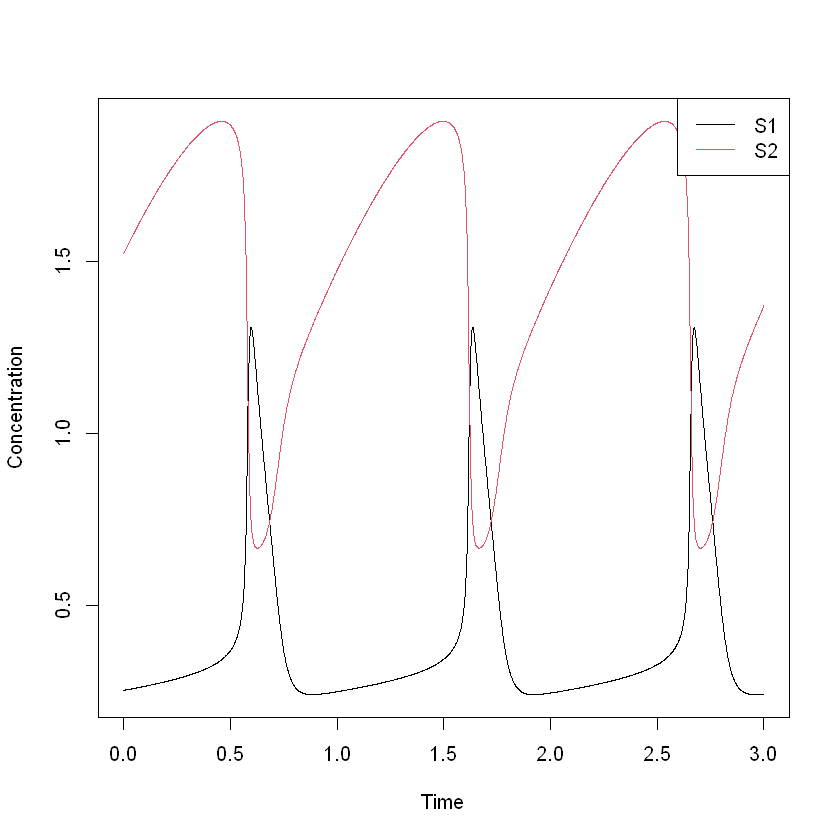

In [29]:
matplot(
  sol[,1], sol[,2:dim(sol)[2]],
  type = "l",
  lty = 1,
  xlab = "Time",
  ylab = "Concentration",
)

legend(
  "topright",
  legend = all_labels,
  col = 1:8,
  lty = 1
)

In [36]:
c("time", all_labels)

[1] "time" "S1"   "S2"

In [38]:
all_of(all_labels)

[1] "S1" "S2"

In [42]:
sol_for_plot <- as.data.frame(sol)

# rename columns for clarity (use time + investigate_label)
colnames(sol_for_plot) <- c("time", all_labels)

# reshape to long format
sol_long <- sol_for_plot %>%
  pivot_longer(cols = all_of(all_labels), names_to = "species", values_to = "value")

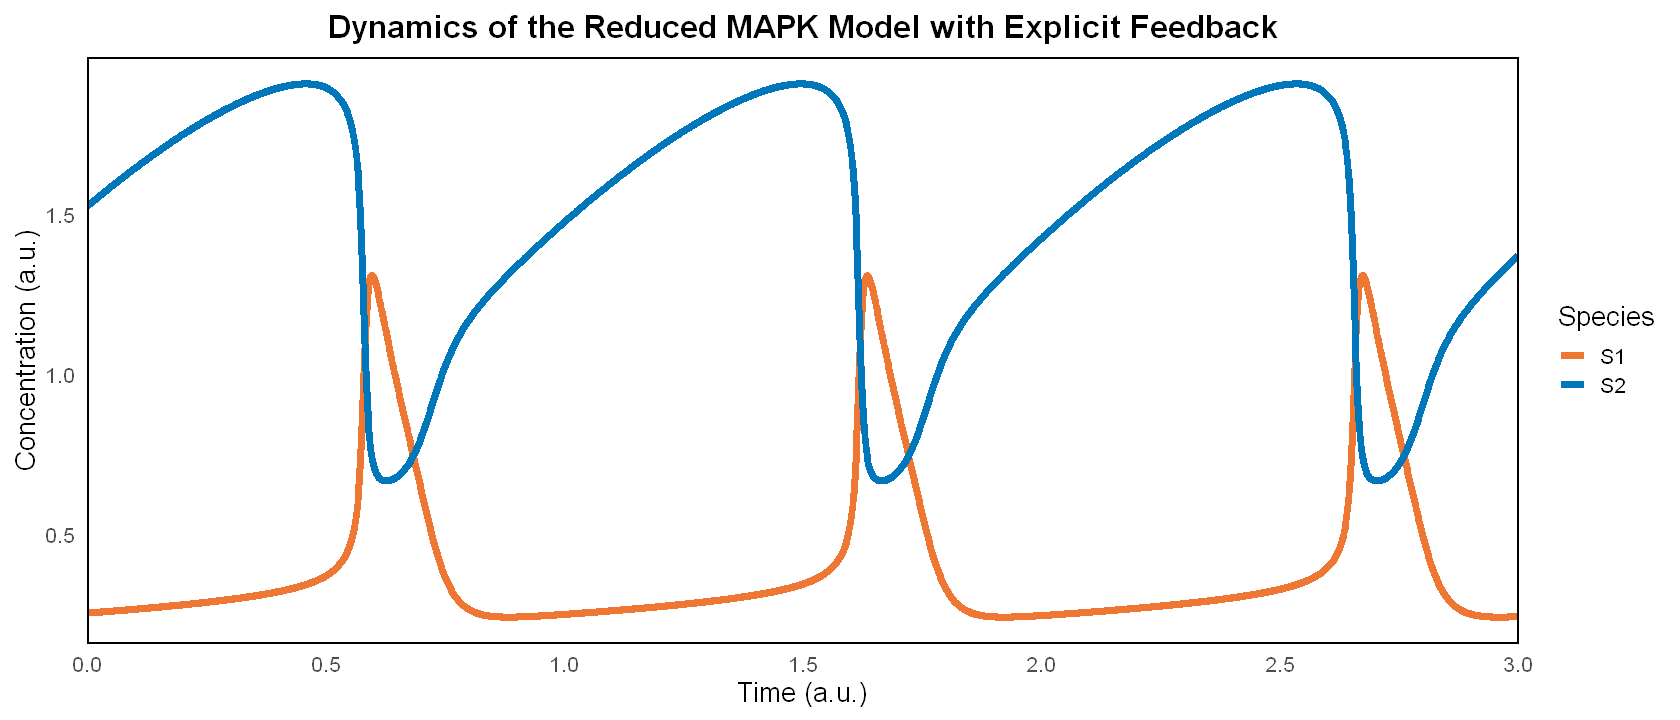

In [ ]:
options(repr.plot.width = 14, repr.plot.height = 6)
colors <- c(
  `S1` = "#EE7733",
  `S2` = "#0077BB"
)

plot1 <- ggplot(sol_long, aes(x = time, y = value, colour = species)) +
  geom_line(linewidth = 2) +
  scale_colour_manual(values = colors) + # scale_colour_brewer(palette = "Dark2") +
  scale_x_continuous(
    breaks = seq(0, 3, 0.5),
    minor_breaks = seq(0, 3, 0.1),
    limits = c(0, 3),
    expand = c(0, 0)
  ) +
  coord_cartesian(xlim = c(0, 3), clip = "on") +
  labs(
    title = "Dynamics of the Calcium Oscillation Model",
    x = "Time (a.u.)",
    y = "Concentration (a.u.)",
    colour = "Species"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5),
    # panel.grid.minor = element_blank(),
    panel.grid = element_blank(),

    ## black outer box
    panel.border = element_rect(
      colour = "black",
      fill = NA,
      linewidth = 1.1
    )
  )

plot1
# ggsave("POSm4_plot.png", plot1, width = 10, height = 8, units = "in", dpi = 300)

In [45]:
sol_list <- lapply(1:nrow(sol), function(i) as.numeric(sol[i, 2:3]))
res_tab_all <- find_loops_vset(model_calcium_oscillation,vset=sol_list,t=1,klin=klin_calcium,kn=kn_calcium,n0=n_calcium)

In [46]:
res_tab_all

loop,length,sign
<I<list>>,<dbl>,<dbl>
"1, 1",1,-1
"2, 2",1,-1
"1, 2, 1",2,1
loop,length,sign
<I<list>>,<dbl>,<dbl>
"1, 1",1,-1
"2, 2",1,-1
"1, 2, 1",2,-1
loop,length,sign


In [47]:
# Draw background in the plot corresponding to the time points where
# certain loop structures are present

# 1-to-1 time vector (must match loop_rep_index length)
time_vec <- sort(unique(sol_long$time))

stopifnot(length(res_tab_all$loop_rep_index) == length(time_vec))

# Run-length encode to get contiguous segments of the same loop structure
r <- rle(res_tab_all$loop_rep_index)

end_idx   <- cumsum(r$lengths)
start_idx <- c(1, head(end_idx + 1, -1))

bands <- tibble(
  loop_type = factor(r$values),
  t_start   = time_vec[start_idx],
  t_end     = time_vec[end_idx]
)
transition_times <- bands$t_end[-nrow(bands)]

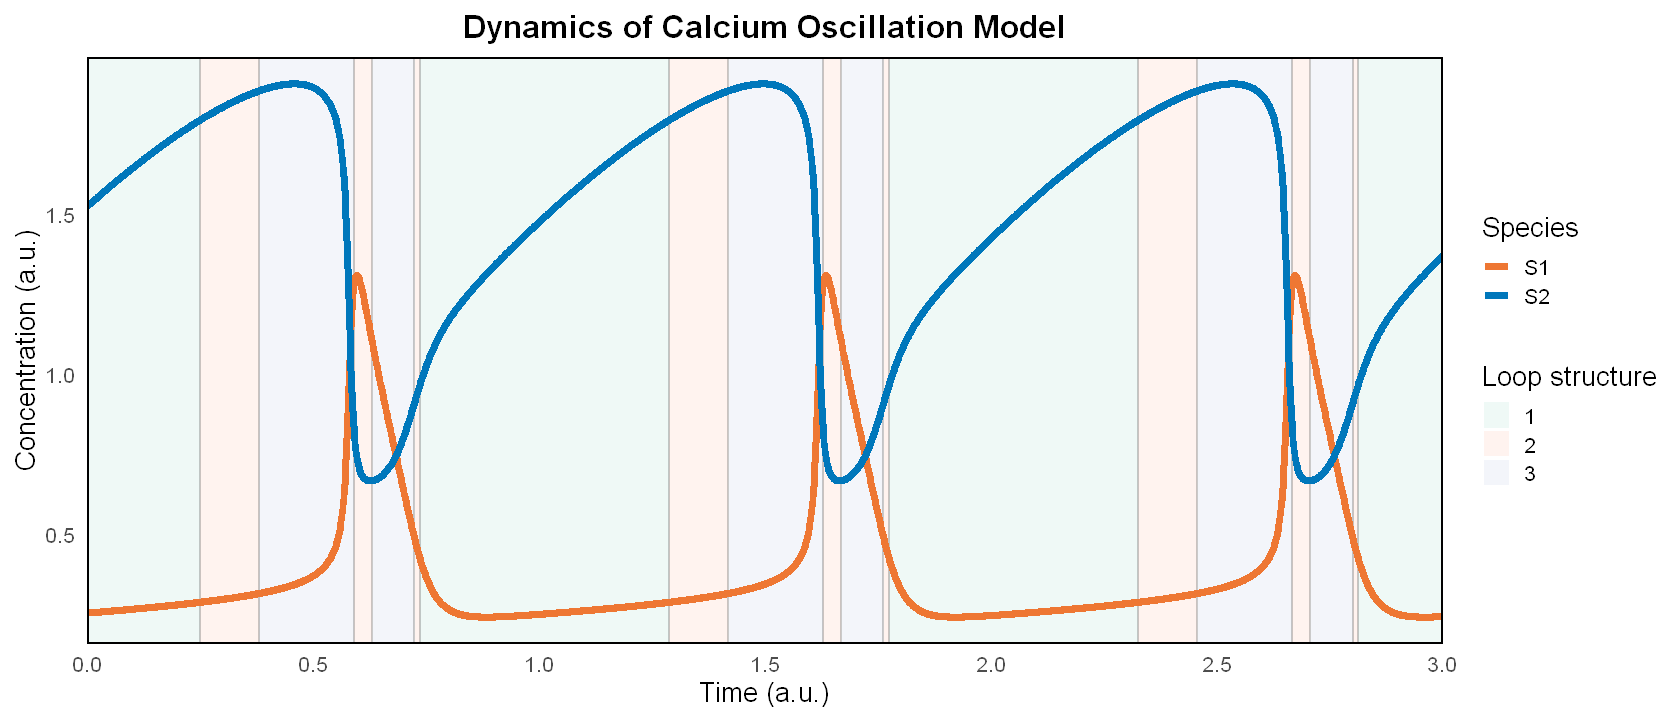

In [48]:
plot2 <- ggplot(sol_long, aes(x = time, y = value, colour = species)) +
  # background bands (behind lines)
  geom_rect(
    data = bands,
    aes(xmin = t_start, xmax = t_end, ymin = -Inf, ymax = Inf, fill = loop_type),
    inherit.aes = FALSE,
    alpha = 0.1
  ) +
  geom_vline(
    xintercept = transition_times,
    colour = "grey40",
    linewidth = 0.7,
    alpha = 0.35
  ) +
  geom_line(linewidth = 2) +
  scale_colour_manual(values = colors) +
  scale_fill_brewer(palette = "Set2", name = "Loop structure") +
  scale_x_continuous(
    breaks = seq(0, 3, 0.5),
    minor_breaks = seq(0, 3, 0.1),
    limits = c(0, 3),
    expand = c(0, 0)
  ) +
  coord_cartesian(xlim = c(0, 3), clip = "on") +
  labs(
    title = "Dynamics of Calcium Oscillation Model",
    x = "Time (a.u.)",
    y = "Concentration (a.u.)",
    colour = "Species"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5),
    panel.grid = element_blank(),
    panel.border = element_rect(colour = "black", fill = NA, linewidth = 1.1)
  )

plot2


In [55]:
print("Loop structure 1:")
res_tab_all$jac_rep

[1] "Loop structure 1:"


-1,1
1,-1
-1,1
-1,-1
1,1
-1,-1


In [54]:
loop_summary(res_tab_all$loop_rep[[1]])

,len_1,len_2
,<dbl>,<dbl>
all,2,1
pos,0,1
neg,2,0


In [56]:
loop_summary(res_tab_all$loop_rep[[2]])

,len_1,len_2
,<dbl>,<dbl>
all,2,1
pos,0,0
neg,2,1


In [57]:
loop_summary(res_tab_all$loop_rep[[3]])

,len_1,len_2
,<dbl>,<dbl>
all,2,1
pos,1,0
neg,1,1
